# Imports (Colab)


In [2]:
from google.colab import userdata
openai_key = userdata.get("OPENAI_KEY")


import openai
import jsonschema
from openai import OpenAI
import pandas as pd
import os
from google.colab import files
from pathlib import Path

client = OpenAI(api_key = openai_key)

false = False
true = True

In [5]:
data_path = Path("/content/fine_tuning_data.xlsx")
jd_df = pd.read_excel(data_path.as_posix())

# Imports (Local)

In [ ]:
api_key = "insert key here"

import openai
import jsonschema
from openai import OpenAI
import pandas as pd
pd.set_option('display.max_colwidth', 100)
import os
from pathlib import Path

client = OpenAI(api_key =api_key)
false = False
true = True

# Load Data & EDA

In [63]:
data_path = "/Users/cyrusaghaee/DS266-Project/data/10k_jd_data.xlsx"
jd_df = pd.read_excel(data_path)
print(jd_df.shape)
jd_df.head()

(10000, 13)


,snapshot_id,id,title,description,location,tax_terms,source_app,company_name,web_url,company,year,month,day
0,f03cda2c-ea7c-4390-b77a-e003916b2e1c,09dac0f5-691f-4296-8ee5-47a6c62a3ec5,Data Science Manager,Who we areAbout Stripe Stripe is a financial infrastructure platform for businesses. Millions of...,"{id=null, city=Seattle, state=WA, country=US, postal_code=98101, lat=47.61133, long=-122.33322}","[""DIRECT_HIRE"", ""FULL_TIME""]",Feed,NaN,https://www.dice.com/job-detail/09dac0f5-691f-4296-8ee5-47a6c62a3ec5,"{id=2056956, company_id=null, name=null, comp_url=null, logo_path=null, dice141=null, absolute_l...",2024,10,31
1,9fed3b49-92e5-404d-8114-00533708559b,7eedd465-2e24-4444-a68d-7ffbe0d8bff9,Data Scientist,Job DescriptionJob DescriptionDescription:Job DescriptionWe are seeking a highly skilled and mot...,"{id=null, city=Indianapolis, state=IN, country=US, postal_code=46201, lat=39.774628, long=-86.10...","[""DIRECT_HIRE"", ""FULL_TIME""]",Feed,"RADcube, LLC",https://www.dice.com/job-detail/7eedd465-2e24-4444-a68d-7ffbe0d8bff9,"{id=2073724, company_id=null, name=RADcube, LLC, comp_url=null, logo_path=null, dice141=null, ab...",2024,10,31
2,7d0a618f-778f-4d17-8ce6-6bf17a45deb1,d169588e-c6d6-43a1-afd3-66ddf11c9729,Quantitative Developer,A technology first company that's known for their algorithmic trading platform is adding to thei...,"{id=null, city=Chicago, state=IL, country=US, postal_code=60601, lat=41.885143, long=-87.62599}","[""DIRECT_HIRE"", ""FULL_TIME""]",Aspen,NaN,https://www.dice.com/job-detail/d169588e-c6d6-43a1-afd3-66ddf11c9729,"{id=1932995, company_id=null, name=null, comp_url=null, logo_path=null, dice141=null, absolute_l...",2024,10,31
3,0194b8e1-7009-4901-8018-6e01048cfa74,345b16c2-b0cd-475e-bb53-ce91203142bf,$60/hour (W2) - REMOTE - Lead Digital Project Manager - Contract,Our government support client is hiring a remote Lead Digital Project Manager at $60/hour (W2) s...,"{id=null, city=null, state=null, country=null, postal_code=null, lat=null, long=null}","[""CONTRACT"", ""CONTRACT_W2""]",Jobman,NaN,https://www.dice.com/job-detail/345b16c2-b0cd-475e-bb53-ce91203142bf,"{id=1307111, company_id=null, name=null, comp_url=null, logo_path=null, dice141=null, absolute_l...",2024,10,31
4,e8ca3775-ac8b-4a9a-b747-a5cfa13e2b26,b9db3c87-2504-4f4e-9b90-608de6e854b2,Cloud Solution Architect (AWS),Job DescriptionJob DescriptionSalary: About Us: Integriti.io is a leading nearshore software dev...,"{id=null, city=Toronto, state=ON, country=US, postal_code=null, lat=null, long=null}","[""DIRECT_HIRE"", ""FULL_TIME""]",Feed,Integriti,https://www.dice.com/job-detail/b9db3c87-2504-4f4e-9b90-608de6e854b2,"{id=2073724, company_id=null, name=Integriti, comp_url=null, logo_path=null, dice141=null, absol...",2024,10,31


In [64]:
null_counts = jd_df.isnull().sum()
print(null_counts)


snapshot_id        0
id                 0
title              0
description        0
location           0
tax_terms          0
source_app        17
company_name    9255
web_url            0
company            0
year               0
month              0
day                0
dtype: int64


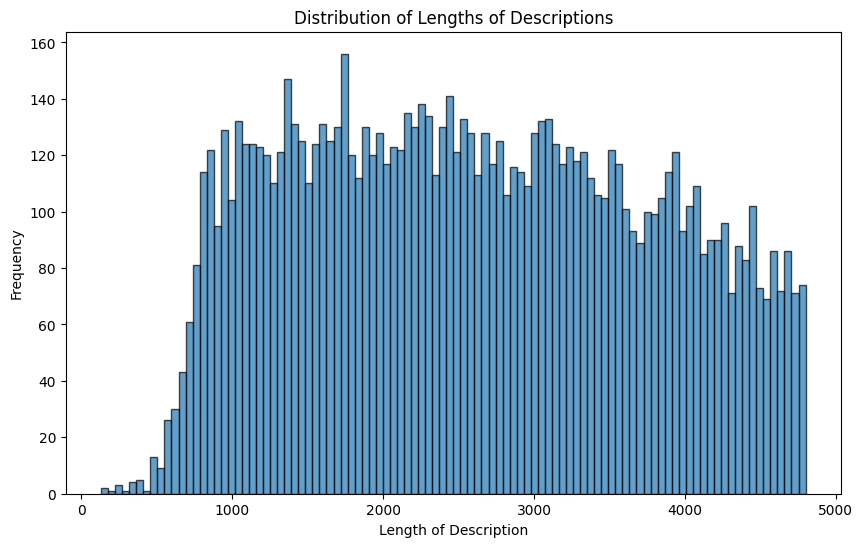

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate the length of descriptions
jd_df['description_length'] = jd_df['description'].str.len()

# Plot the distribution of lengths
plt.figure(figsize=(10, 6))
plt.hist(jd_df['description_length'].dropna(), bins=100, edgecolor='k', alpha=0.7)
plt.title('Distribution of Lengths of Descriptions')
plt.xlabel('Length of Description')
plt.ylabel('Frequency')
plt.show()

In [66]:
import numpy as np

# Drop any missing values in the description_length column
lengths = jd_df['description_length'].dropna()

# Calculate the 5th percentiles
percentiles = [np.percentile(lengths, i) for i in range(0, 101, 5)]

# Print the values at every 5th percentile
for i, value in enumerate(percentiles):
    print(f"{i*5}th Percentile: {value}")


0th Percentile: 130.0
5th Percentile: 870.95
10th Percentile: 1072.0
15th Percentile: 1264.85
20th Percentile: 1446.0
25th Percentile: 1636.75
30th Percentile: 1814.0
35th Percentile: 2001.0
40th Percentile: 2190.0
45th Percentile: 2372.0
50th Percentile: 2548.0
55th Percentile: 2739.0
60th Percentile: 2944.199999999999
65th Percentile: 3129.0
70th Percentile: 3322.2999999999993
75th Percentile: 3532.25
80th Percentile: 3761.2000000000007
85th Percentile: 3977.0
90th Percentile: 4217.1
95th Percentile: 4493.0
100th Percentile: 4800.0


# Create Prompts

In [67]:
extraction_prompt = "You are a tool used to extract the requirements and responsibilities from a job description. I will be inputting a series of job descriptions, so please use the following prompt:\n\nFirst, extract the technical skill requirements and responsibilities from the job description as JSON by following these steps:\nStep 1 - Technical skills should be defined as: specific abilities that relate to the use of tools, technologies, programming languages, software applications, or technical processes.\nStep 2 - Extract the technical skills that are explicitly stated in the job description. You must not include soft skills or job titles. You must include any technical skills that are listed as an experience requirement.\nStep 3 - Store each of the technical skills in a key called 'skill_name' under an object called “technical_skills”.\nStep 4 - If multiple technical skills in a phrase are grouped using parentheses or listed using grouping connectors similar to \"including\", \"like\", \"/\", \"or\", or \"such as\" then list the skills in one array so that they result in a single skill_name. If technical skills are listed without grouping connectors and in a phrase ending in \"and\" then treat each listed skill as a separate skill_name. When skills are listed with no clear grouping implied, list each skill individually rather than in an array.  Below are examples of desired outputs:\nExample phrase 1 -  \"experience of 6+ years using cybersecurity architectures, IDS/IPS, SIEM tools, or firewalls\"\nExample output 1 - skill_name: [cybersecurity architectures, IDS/IPS, SIEM tools, firewalls]\nExample phrase 2 - \"knowledge of database systems including MySQL, PostgreSQL, and Redis\" \nExample output 2 - skill_name: [database systems, MySQL, PostgreSQL, Redis]\nExample phrase 3  - \"4+ years experience with Java/JEE, SOAP/REST/Micro Services, XML\"\nExample output 3 (3 separate skill_name keys) - skill_name: [Java, JEE], skill_name: [SOAP, REST, Micro Services], skill_name: [XML] \nExample phrase 4  - \"experience with SQL Server, Oracle, MongoDB\" \nExample output 4 (3 separate skill_name keys) - skill_name: [SQL Server], skill_name: [Oracle], skill_name: [MongoDB]\nExample phrase 5 -  \"4 or more years experience with messaging architectures (EAI), SAP XI, BizTalk, and Web Services\" \nExample output 5 (4 separate skill_name keys) - skill_name: [messaging architectures, EAI], skill_name: [SAP XI], skill_name: [BizTalk], skill_name: [Web Services]\nExample phrase 6 - \"AWS Knowledge: Event Bridge, Cloud Watch, Cloud Trail\"\nExample output 6 (4 separate skill_name keys) - skill_name: [AWS], skill_name: [Event Bridge], skill_name: [Cloud Watch], skill_name: [Cloud Trail],\nExample phrase 7 - \"Working knowledge of EDB, Oracle, and AWS operations (S3, EC2).\"\nExample output 7 (3 separate skill_name keys) - skill_name: [EDB], skill_name: [Oracle], skill_name: [AWS Operations, S3, EC2]\nExample phrase 8 - \"expertise in the SAP Analytics Roadmap and new technologies such as SAP HANA, and SAP SAC.\"\nExample output 8 (2 separate skill_name keys) - skill_name: [SAP Analytics Roadmap], skill_name: [SAP HANA, SAP SAC]\nExample phrase 9 - \"Demonstrated understanding of WAN, LAN, and VPN networks, including the relationship between network infrastructure and IP-enabled devices.\"\nExample output 9 (4 separate skill_name keys) - skill_name: [WAN], skill_name: [LAN], skill_name: [VPN networks], skill_name: [network infrastructure, IP-enabled devices]\nStep 5 - Classify each of the technical skills that are described as mandatory, essential, needed, or similar as ‘required’. Classify the technical skills that are described as preferred, nice to have, or similar as ‘preferred’. If a requirement is not mentioned or not clear, then classify it as ‘preferred’. If a technical skill is only described under job responsibilities or job duties then classify it as 'preferred'. Separate the skills under two objects called ‘required’ and ‘preferred’.\nStep 6 - For each skill, extract the minimum years required explicitly stated for that specific skill (not inferred or through association) and list 0 if years are not explicitly stated for that specific skill. If a range of years is given, use the smallest year. Label these using a key called ‘minyears’.\nStep 7 - If any two technical skills you have extracted are extremely similar, merge them into a single skill_name array.\n\nNext, extract the required level of education from the job description as JSON by following these steps:\nStep 1 - Locate the requirements, qualifications, prerequisite, or a similar section of the job description and extract any educational requirements that are explicitly stated.\nStep 2 - Create a key called ‘education_level’ that lists the levels of education mentioned in the job qualifications. Categorize the levels of education under one of the following values that fits best: High School Diploma, Associate's, Current Bachelor's Student, Bachelor’s, Current Master's Student, Master’s, Doctorate, Postdoctorate, Vocational, None.\nStep 3 - Classify the levels of education that are explicitly described as mandatory, essential, required, or similar as ‘required’. Classify the levels of education that are explicitly described as preferred, nice to have, or similar as ‘preferred’.  If a qualification is not mentioned, then classify the level of education as ‘preferred’.  Separate these levels of education under two objects called ‘required’ and ‘preferred’.\nStep 4 - If more than one level of education meets the necessary requirement, classify the higher levels of education as 'preferred'. If multiple levels of education are preferred, store them all as one level of education using an array of comma separated values. As a result, there should only be one 'education_level' key in each of the 'required' and 'preferred' object. For example, phrases like \"A Bachelor's is required, a Master's/PhD is preferred\" would have Bachelor's under the 'required' object but [Master's, Doctorate] under the 'preferred' object.\nStep 5 - If experience is an acceptable alternative to an education requirement, add 'Or Experience' as a value into the 'education_level' array, but only if there is an existing education level. Below are examples of desired outputs:\nExample phrase 1 - \"a Master's degree in mathematics, STEM, or a related field, or 2 years of experience\"\nExample output 1 - education_level: [Master's, Or Experience] \nExample phrase 2- \" graduate in information systems or equivalent hands-on work experience\"\nExample output 2 - education_level: [Bachelor's, Or Experience] \nExample phrase 3 - \"**Option A**: Bachelor's or higher degree with at least 30 semester hours in mathematics and physical sciences.- **Option B**: Combination of education and experience equivalent to a 4-year course of study.\"\nExample output 3- education_level: [Current Bachelor's, Or Experience] \nStep 6 - For each level of education in the list, identify and include any fields of study mentioned in a key called ‘field_of_study’ as separate values in an array. If terms like  \"or similar\", \"or equivalent\", or \"or related\" are used, include ‘Related’ as a field of study. If no fields of study are listed then do not list anything. Below are examples of desired outputs:\nExample phrase 1 - \"A Bachelor's degree in Computer Science, STEM, or a related field\"\nExample output 1 - field_of_study: [Computer Science, STEM, Related]\nExample phrase 2 - \"A graduate in Computer Science, Business, STEM, or equivalent\"\nExample output 2 - field_of_study: [Computer Science, STEM, Related]\n\nNext extract any required credentials, certifications, licenses, or similar credentials from the job description as JSON by following these steps:\nStep 1 - Search within the job description for certifications, licenses, security clearances, or similar credential qualifications that are related to the job. \nStep 2 - Extract the names of any certifications, licenses, security clearances, or similar credentials that are explicitly stated under keys called ‘credential’. Do not include credential qualifications that are not related to the job like driver's licenses, citizenship documentation, or other unrelated credentials.\nStep 3 - If multiple options are acceptable, place them in an array under the credential. If both a credential and it's abbreviation/acronym are given, provide both in the array. Below are examples of desired outputs:\nExample phrase 1 - \"Certified as IAT or IAM Level III\"\nExample output 1- field_of_study:  [IAM Level III Certification, IAT Level III Certification]\nExample phrase 2 - \"CCNP (Cisco Certified Network Professional)\"\nExample output 2 - field_of_study:  [CCNP, Cisco Certified Network Professional]\nStep 4 - Classify each of these credentials that are explicitly described as mandatory, essential, required, or similar as ‘required’. Classify the credentials that are explicitly described as preferred, nice to have, or similar as ‘preferred’. If a qualification is not mentioned, then classify the credential as ‘preferred’. Separate these credentials under two objects called ‘required’ and ‘preferred’.\nStep 5 - If any certifications, licenses, security clearances, or similar credentials are listed as a technical skill, you must remove them from the technical skill section.\nStep 6 - The output should be structured under the key ‘Credentials’, under objects for ‘required’ and ‘preferred’.\n\nNext, extract the experience requirements from the job description as JSON by following these steps:\nStep 1 - Experience is defined as: The amount and type of prior work experience a candidate must have in order to qualify for the job or to complete the duties of the job. This includes the level of seniority, industry background, job responsibilities, and job duties but does not include technical skills.\nStep 2 - Identify and extract any experience requirements that are explicitly stated in the job description.\nStep 3 - Create a key for each experience requirement under a key called 'experience_desc'. \nStep 4 - Review the experience requirements and if any of them involve technical skills then you must remove them.\nStep 5 - If multiple experiences in a phrase are grouped using parentheses or listed using grouping connectors similar to \"including\", \"like\", \"/\", \"or\", or \"such as\" then you must list the experiences in one array so that they result in a single experience_desc. If experiences are listed without grouping connectors and listed in a phrase ending in \"and\" then you must treat each listed experience as a separate experience_desc. When no clear grouping is implied then you must list each experience individually rather than in an array. Below are examples of desired outputs:\nExample phrase 1 - \"7+ years overall experience in product management, marketing analysis, or professional services\"\nExample output 1 - experience_desc: [product management, marketing analysis, professional services]\nExample phrase 2 - \"must have leadership experience (manager, director, or VP level)\"\nExample output 2 - experience_desc: [manager, director, VP]\nExample phrase 3 - \"3+ years in designing, implementing, and optimizing custom solutions for enterprise software applications\"\nExample output 3 (3 separate experience_desc keys) - experience_desc: [designing custom solutions for enterprise software applications], experience_desc: [implementing custom solutions for enterprise software applications], experience_desc: [optimizing custom solutions for enterprise software applications]\nExample phrase 4 - \"1-2 years of experience leading software teams and working in an agile, kanban, or scrum environment\"\nExample output 4 (2 separate experience_desc keys) - experience_desc: [leading software teams], experience_desc: [agile environment, kanban environment, scrum environment]\nExample phrase 5 - \"professional experience with version/source control, design/application, development principles/methodologies, integration tools\"\nExample output 5 (4 separate experience_desc keys) - experience_desc: [version control, source control], experience_desc: [design, application], experience_desc: [development principles, development methodologies], experience_desc: [integration tools]  \nStep 6 - If terms like \"or similar\", \"or equivalent\", or \"or related\" are used to describe an experience requirement you must include ‘Related’ in the array.  Below are examples of desired outputs:\nExample phrase 1 - \"experience as a data scientist or a related role\"\nExample output 1 - experience_desc: [data scientist, Related]\nExample phrase 2 - \"5+ years of data engineering experience or equivalent\"\nExample output 2 - experience_desc: [data engineering, Related]\nStep 7 - If experience is listed as a requirement without specifying a type of experience, then list the experience as 'Work Experience'. Below are examples of desired outputs:\nExample phrase 1 - \"4+ years of experience are required\"\nExample output 1 - experience_desc: [Work Experience]\nExample phrase 2 - \"Experience Required: 5 years\"\nExample output 2 - experience_desc: [Work Experience]\nStep 8 - Identify the education requirements in the job description. For any phrasing that includes work experience as an alternative to an education requirement, such as \"equivalent experience\", \"equivalent hands-on work experience\", \"relevant experience\", or \"professional experience\" you must include an additional experience_desc key with the values [Work Experience, Or Education]. You must apply this rule to any phrasing where work experience is presented as an acceptable substitute for an education requirement. Below are examples of desired outputs:\nExample phrase 1 - \"An degree in engineering or 3+ years of relevant experience\"\nExample output 1 - experience_desc: [Work Experience, Or Education] \nExample phrase 2 - \"A Bachelor's degree in computer science (or equivalent experience) is needed\" \nExample output 2 - experience_desc: [Work Experience, Or Education] \nExample phrase 3 - \"Master of Science degree in computer science, MIS, or equivalent hands-on work experience\"\nExample output 3 - experience_desc: [Work Experience, Or Education] \nExample phrase 4 - \"A degree from an accredited university preferred, but related experience is also allowed\"\nExample output 4 - experience_desc: [Work Experience, Or Education] \nStep 9 - For each experience_desc in the list, identify and include any industries mentioned in a key called ‘industry’ as separate values in an array. If terms like  \"or similar\", \"or equivalent\", or \"or related\" are used, include ‘Related’ as an industry.  If no industries are listed then do not list anything. Below are examples of desired outputs:\nExample phrase 1 - \"Minimum of 5+ years of experience as a Project Manager / Scrum Master in the AI/ML industry\"\nExample output 1 - industry: [AI Industry, ML Industry]\nExample phrase 2 - \"7 years of data analyst experience in SaaS\"\nExample output 2 - industry: [SaaS]\nExample phrase 3 - \"Proven leadership experience in fintech or a related industry\"\nExample output 3 - industry: [fintech, Related]\nStep 10 - Classify each of the experiences that are explicitly described as mandatory, essential, required, or similar as ‘required’. Classify the experiences that are explicitly described as preferred, nice to have, or similar as ‘preferred’. If a requirement is not mentioned or not clear, then classify the experience as ‘preferred’. If an experience is only described under job responsibilities or job duties then classify it as 'preferred'. Separate these experiences under two objects called ‘required’ and ‘preferred’.\nStep 11 - Review each experience, and if any experiences contain technical skills within them remove them from the experience requirements and then add them to the technical skills requirements.\nStep 12 - If any industries under 'required' are described as preferred then remove the industry.\nExample phrase 1 - \"2+ years of experience in Information Technology, preferably in the semiconductor industry\"\nExample output 1 - industry: []\nExample phrase 2 - \"4 years of experience as a data engineer are required, within the finance industry preferred\"\nExample output 2 - industry: []\nStep 13 - For each experience, list the minimum years of experience that is explicitly specified for that experience and list 0 if years are not explicitly specified. If a range of years is given, give the smallest year. Label these using a key called ‘minyears’.\n\nLastly, clean and organize the extracted requirements and responsibilities by following these steps:\nStep 1 - If the job description contains the requirements for multiple positions or multiple levels of a position, you must only keep the 'required' qualifications that are relevant to the lowest position or most entry level position and then treat the rest of the qualifications as 'preferred'.\nStep 2 - Combine the JSON outputs from skills, education, credentials, and experience into one JSON. \nStep 3 - Organize the data under two main objects: 'required' and 'preferred', moving the respective skills, education, credentials, and experience under them accordingly. \nStep 4 - Output the combined JSON."

In [94]:
print(len(extraction_prompt))

17107


In [ ]:

print(extraction_prompt)

You are a tool used to extract the requirements and responsibilities from a job description. I will be inputting a series of job descriptions, so please use the following prompt:

First, extract the technical skill requirements and responsibilities from the job description as JSON by following these steps:
Step 1 - Technical skills should be defined as: specific abilities that relate to the use of tools, technologies, programming languages, software applications, or technical processes.
Step 2 - Extract the technical skills that are explicitly stated in the job description. You must not include soft skills or job titles. You must include any technical skills that are listed as an experience requirement.
Step 3 - Store each of the technical skills in a key called 'skill_name' under an object called “technical_skills”.
Step 4 - If multiple technical skills in a phrase are grouped using parentheses or listed using grouping connectors similar to "including", "like", "/", "or", or "such as"

In [69]:
def reformat_desc(desc):
  response = client.chat.completions.create(
    model="gpt-4o",
    messages=[
      {
        "role": "system",
        "content": [
          {
            "text": "You are a tool used to organize and reformat job descriptions into a structured markdown format that is optimized for information extraction from the ChatGPT 4o model. You must retain all information from the job description that is related to job requirements, job qualifications, job responsibilities, or job duties. You must exclude any information related to descriptions of the company, team, salary, travel, location, culture, application process, physical requirements/demands, or benefits. After, output the reformatted job description in markdown format.",
            "type": "text"
          }
        ]
      },
      {
        "role": "user",
        "content": [
          {
            "type": "text",
            "text": desc
          }
        ]
      }
    ],
    response_format={
      "type": "text"
    },
    seed=42,
    temperature=0,
    max_tokens=6400,
    top_p=1,
    frequency_penalty=0,
    presence_penalty=0
  )

  return response

In [70]:
def extract_job_requirements(description):

 response = client.chat.completions.create(
    model="gpt-4o",
    messages=[
        {
        "role": "system",
        "content": [
            {
            "text": "You are a tool used to extract the requirements and responsibilities from a job description. I will be inputting a series of job descriptions, so please use the following prompt:\n\nFirst, extract the technical skill requirements and responsibilities from the job description as JSON by following these steps:\nStep 1 - Technical skills should be defined as: specific abilities that relate to the use of tools, technologies, programming languages, software applications, or technical processes.\nStep 2 - Extract the technical skills that are explicitly stated in the job description. You must not include soft skills or job titles. You must include any technical skills that are listed as an experience requirement.\nStep 3 - Store each of the technical skills in a key called 'skill_name' under an object called “technical_skills”.\nStep 4 - If multiple technical skills in a phrase are grouped using parentheses or listed using grouping connectors similar to \"including\", \"like\", \"/\", \"or\", or \"such as\" then list the skills in one array so that they result in a single skill_name. If technical skills are listed without grouping connectors and in a phrase ending in \"and\" then treat each listed skill as a separate skill_name. When skills are listed with no clear grouping implied, list each skill individually rather than in an array.  Below are examples of desired outputs:\nExample phrase 1 -  \"experience of 6+ years using cybersecurity architectures, IDS/IPS, SIEM tools, or firewalls\"\nExample output 1 - skill_name: [cybersecurity architectures, IDS/IPS, SIEM tools, firewalls]\nExample phrase 2 - \"knowledge of database systems including MySQL, PostgreSQL, and Redis\" \nExample output 2 - skill_name: [database systems, MySQL, PostgreSQL, Redis]\nExample phrase 3  - \"4+ years experience with Java/JEE, SOAP/REST/Micro Services, XML\"\nExample output 3 (3 separate skill_name keys) - skill_name: [Java, JEE], skill_name: [SOAP, REST, Micro Services], skill_name: [XML] \nExample phrase 4  - \"experience with SQL Server, Oracle, MongoDB\" \nExample output 4 (3 separate skill_name keys) - skill_name: [SQL Server], skill_name: [Oracle], skill_name: [MongoDB]\nExample phrase 5 -  \"4 or more years experience with messaging architectures (EAI), SAP XI, BizTalk, and Web Services\" \nExample output 5 (4 separate skill_name keys) - skill_name: [messaging architectures, EAI], skill_name: [SAP XI], skill_name: [BizTalk], skill_name: [Web Services]\nExample phrase 6 - \"AWS Knowledge: Event Bridge, Cloud Watch, Cloud Trail\"\nExample output 6 (4 separate skill_name keys) - skill_name: [AWS], skill_name: [Event Bridge], skill_name: [Cloud Watch], skill_name: [Cloud Trail],\nExample phrase 7 - \"Working knowledge of EDB, Oracle, and AWS operations (S3, EC2).\"\nExample output 7 (3 separate skill_name keys) - skill_name: [EDB], skill_name: [Oracle], skill_name: [AWS Operations, S3, EC2]\nExample phrase 8 - \"expertise in the SAP Analytics Roadmap and new technologies such as SAP HANA, and SAP SAC.\"\nExample output 8 (2 separate skill_name keys) - skill_name: [SAP Analytics Roadmap], skill_name: [SAP HANA, SAP SAC]\nExample phrase 9 - \"Demonstrated understanding of WAN, LAN, and VPN networks, including the relationship between network infrastructure and IP-enabled devices.\"\nExample output 9 (4 separate skill_name keys) - skill_name: [WAN], skill_name: [LAN], skill_name: [VPN networks], skill_name: [network infrastructure, IP-enabled devices]\nStep 5 - Classify each of the technical skills that are described as mandatory, essential, needed, or similar as ‘required’. Classify the technical skills that are described as preferred, nice to have, or similar as ‘preferred’. If a requirement is not mentioned or not clear, then classify it as ‘preferred’. If a technical skill is only described under job responsibilities or job duties then classify it as 'preferred'. Separate the skills under two objects called ‘required’ and ‘preferred’.\nStep 6 - For each skill, extract the minimum years required explicitly stated for that specific skill (not inferred or through association) and list 0 if years are not explicitly stated for that specific skill. If a range of years is given, use the smallest year. Label these using a key called ‘minyears’.\nStep 7 - If any two technical skills you have extracted are extremely similar, merge them into a single skill_name array.\n\nNext, extract the required level of education from the job description as JSON by following these steps:\nStep 1 - Locate the requirements, qualifications, prerequisite, or a similar section of the job description and extract any educational requirements that are explicitly stated.\nStep 2 - Create a key called ‘education_level’ that lists the levels of education mentioned in the job qualifications. Categorize the levels of education under one of the following values that fits best: High School Diploma, Associate's, Current Bachelor's Student, Bachelor’s, Current Master's Student, Master’s, Doctorate, Postdoctorate, Vocational, None.\nStep 3 - Classify the levels of education that are explicitly described as mandatory, essential, required, or similar as ‘required’. Classify the levels of education that are explicitly described as preferred, nice to have, or similar as ‘preferred’.  If a qualification is not mentioned, then classify the level of education as ‘preferred’.  Separate these levels of education under two objects called ‘required’ and ‘preferred’.\nStep 4 - If more than one level of education meets the necessary requirement, classify the higher levels of education as 'preferred'. If multiple levels of education are preferred, store them all as one level of education using an array of comma separated values. As a result, there should only be one 'education_level' key in each of the 'required' and 'preferred' object. For example, phrases like \"A Bachelor's is required, a Master's/PhD is preferred\" would have Bachelor's under the 'required' object but [Master's, Doctorate] under the 'preferred' object.\nStep 5 - If experience is an acceptable alternative to an education requirement, add 'Or Experience' as a value into the 'education_level' array, but only if there is an existing education level. Below are examples of desired outputs:\nExample phrase 1 - \"a Master's degree in mathematics, STEM, or a related field, or 2 years of experience\"\nExample output 1 - education_level: [Master's, Or Experience] \nExample phrase 2- \" graduate in information systems or equivalent hands-on work experience\"\nExample output 2 - education_level: [Bachelor's, Or Experience] \nExample phrase 3 - \"**Option A**: Bachelor's or higher degree with at least 30 semester hours in mathematics and physical sciences.- **Option B**: Combination of education and experience equivalent to a 4-year course of study.\"\nExample output 3- education_level: [Current Bachelor's, Or Experience] \nStep 6 - For each level of education in the list, identify and include any fields of study mentioned in a key called ‘field_of_study’ as separate values in an array. If terms like  \"or similar\", \"or equivalent\", or \"or related\" are used, include ‘Related’ as a field of study. If no fields of study are listed then do not list anything. Below are examples of desired outputs:\nExample phrase 1 - \"A Bachelor's degree in Computer Science, STEM, or a related field\"\nExample output 1 - field_of_study: [Computer Science, STEM, Related]\nExample phrase 2 - \"A graduate in Computer Science, Business, STEM, or equivalent\"\nExample output 2 - field_of_study: [Computer Science, STEM, Related]\n\nNext extract any required credentials, certifications, licenses, or similar credentials from the job description as JSON by following these steps:\nStep 1 - Search within the job description for certifications, licenses, security clearances, or similar credential qualifications that are related to the job. \nStep 2 - Extract the names of any certifications, licenses, security clearances, or similar credentials that are explicitly stated under keys called ‘credential’. Do not include credential qualifications that are not related to the job like driver's licenses, citizenship documentation, or other unrelated credentials.\nStep 3 - If multiple options are acceptable, place them in an array under the credential. If both a credential and it's abbreviation/acronym are given, provide both in the array. Below are examples of desired outputs:\nExample phrase 1 - \"Certified as IAT or IAM Level III\"\nExample output 1- field_of_study:  [IAM Level III Certification, IAT Level III Certification]\nExample phrase 2 - \"CCNP (Cisco Certified Network Professional)\"\nExample output 2 - field_of_study:  [CCNP, Cisco Certified Network Professional]\nStep 4 - Classify each of these credentials that are explicitly described as mandatory, essential, required, or similar as ‘required’. Classify the credentials that are explicitly described as preferred, nice to have, or similar as ‘preferred’. If a qualification is not mentioned, then classify the credential as ‘preferred’. Separate these credentials under two objects called ‘required’ and ‘preferred’.\nStep 5 - If any certifications, licenses, security clearances, or similar credentials are listed as a technical skill, you must remove them from the technical skill section.\nStep 6 - The output should be structured under the key ‘Credentials’, under objects for ‘required’ and ‘preferred’.\n\nNext, extract the experience requirements from the job description as JSON by following these steps:\nStep 1 - Experience is defined as: The amount and type of prior work experience a candidate must have in order to qualify for the job or to complete the duties of the job. This includes the level of seniority, industry background, job responsibilities, and job duties but does not include technical skills.\nStep 2 - Identify and extract any experience requirements that are explicitly stated in the job description.\nStep 3 - Create a key for each experience requirement under a key called 'experience_desc'. \nStep 4 - Review the experience requirements and if any of them involve technical skills then you must remove them.\nStep 5 - If multiple experiences in a phrase are grouped using parentheses or listed using grouping connectors similar to \"including\", \"like\", \"/\", \"or\", or \"such as\" then you must list the experiences in one array so that they result in a single experience_desc. If experiences are listed without grouping connectors and listed in a phrase ending in \"and\" then you must treat each listed experience as a separate experience_desc. When no clear grouping is implied then you must list each experience individually rather than in an array. Below are examples of desired outputs:\nExample phrase 1 - \"7+ years overall experience in product management, marketing analysis, or professional services\"\nExample output 1 - experience_desc: [product management, marketing analysis, professional services]\nExample phrase 2 - \"must have leadership experience (manager, director, or VP level)\"\nExample output 2 - experience_desc: [manager, director, VP]\nExample phrase 3 - \"3+ years in designing, implementing, and optimizing custom solutions for enterprise software applications\"\nExample output 3 (3 separate experience_desc keys) - experience_desc: [designing custom solutions for enterprise software applications], experience_desc: [implementing custom solutions for enterprise software applications], experience_desc: [optimizing custom solutions for enterprise software applications]\nExample phrase 4 - \"1-2 years of experience leading software teams and working in an agile, kanban, or scrum environment\"\nExample output 4 (2 separate experience_desc keys) - experience_desc: [leading software teams], experience_desc: [agile environment, kanban environment, scrum environment]\nExample phrase 5 - \"professional experience with version/source control, design/application, development principles/methodologies, integration tools\"\nExample output 5 (4 separate experience_desc keys) - experience_desc: [version control, source control], experience_desc: [design, application], experience_desc: [development principles, development methodologies], experience_desc: [integration tools]  \nStep 6 - If terms like \"or similar\", \"or equivalent\", or \"or related\" are used to describe an experience requirement you must include ‘Related’ in the array.  Below are examples of desired outputs:\nExample phrase 1 - \"experience as a data scientist or a related role\"\nExample output 1 - experience_desc: [data scientist, Related]\nExample phrase 2 - \"5+ years of data engineering experience or equivalent\"\nExample output 2 - experience_desc: [data engineering, Related]\nStep 7 - If experience is listed as a requirement without specifying a type of experience, then list the experience as 'Work Experience'. Below are examples of desired outputs:\nExample phrase 1 - \"4+ years of experience are required\"\nExample output 1 - experience_desc: [Work Experience]\nExample phrase 2 - \"Experience Required: 5 years\"\nExample output 2 - experience_desc: [Work Experience]\nStep 8 - Identify the education requirements in the job description. For any phrasing that includes work experience as an alternative to an education requirement, such as \"equivalent experience\", \"equivalent hands-on work experience\", \"relevant experience\", or \"professional experience\" you must include an additional experience_desc key with the values [Work Experience, Or Education]. You must apply this rule to any phrasing where work experience is presented as an acceptable substitute for an education requirement. Below are examples of desired outputs:\nExample phrase 1 - \"An degree in engineering or 3+ years of relevant experience\"\nExample output 1 - experience_desc: [Work Experience, Or Education] \nExample phrase 2 - \"A Bachelor's degree in computer science (or equivalent experience) is needed\" \nExample output 2 - experience_desc: [Work Experience, Or Education] \nExample phrase 3 - \"Master of Science degree in computer science, MIS, or equivalent hands-on work experience\"\nExample output 3 - experience_desc: [Work Experience, Or Education] \nExample phrase 4 - \"A degree from an accredited university preferred, but related experience is also allowed\"\nExample output 4 - experience_desc: [Work Experience, Or Education] \nStep 9 - For each experience_desc in the list, identify and include any industries mentioned in a key called ‘industry’ as separate values in an array. If terms like  \"or similar\", \"or equivalent\", or \"or related\" are used, include ‘Related’ as an industry.  If no industries are listed then do not list anything. Below are examples of desired outputs:\nExample phrase 1 - \"Minimum of 5+ years of experience as a Project Manager / Scrum Master in the AI/ML industry\"\nExample output 1 - industry: [AI Industry, ML Industry]\nExample phrase 2 - \"7 years of data analyst experience in SaaS\"\nExample output 2 - industry: [SaaS]\nExample phrase 3 - \"Proven leadership experience in fintech or a related industry\"\nExample output 3 - industry: [fintech, Related]\nStep 10 - Classify each of the experiences that are explicitly described as mandatory, essential, required, or similar as ‘required’. Classify the experiences that are explicitly described as preferred, nice to have, or similar as ‘preferred’. If a requirement is not mentioned or not clear, then classify the experience as ‘preferred’. If an experience is only described under job responsibilities or job duties then classify it as 'preferred'. Separate these experiences under two objects called ‘required’ and ‘preferred’.\nStep 11 - Review each experience, and if any experiences contain technical skills within them remove them from the experience requirements and then add them to the technical skills requirements.\nStep 12 - If any industries under 'required' are described as preferred then remove the industry.\nExample phrase 1 - \"2+ years of experience in Information Technology, preferably in the semiconductor industry\"\nExample output 1 - industry: []\nExample phrase 2 - \"4 years of experience as a data engineer are required, within the finance industry preferred\"\nExample output 2 - industry: []\nStep 13 - For each experience, list the minimum years of experience that is explicitly specified for that experience and list 0 if years are not explicitly specified. If a range of years is given, give the smallest year. Label these using a key called ‘minyears’.\n\nLastly, clean and organize the extracted requirements and responsibilities by following these steps:\nStep 1 - If the job description contains the requirements for multiple positions or multiple levels of a position, you must only keep the 'required' qualifications that are relevant to the lowest position or most entry level position and then treat the rest of the qualifications as 'preferred'.\nStep 2 - Combine the JSON outputs from skills, education, credentials, and experience into one JSON. \nStep 3 - Organize the data under two main objects: 'required' and 'preferred', moving the respective skills, education, credentials, and experience under them accordingly. \nStep 4 - Output the combined JSON.",
            "type": "text"
            }
        ]
        },
        {
        "role": "user",
        "content": [
            {
            "type": "text",
            "text": description
            }
        ]
        }
    ],
    response_format={
        "type": "json_schema",
        "json_schema": {
        "name": "job_requirements",
        "schema": {
            "type": "object",
            "required": [
            "Required",
            "Preferred"
            ],
            "properties": {
            "Required": {
                "type": "object",
                "required": [
                "Technical_skills",
                "Education",
                "Credentials",
                "Experience"
                ],
                "properties": {
                "Education": {
                    "type": "array",
                    "items": {
                    "type": "object",
                    "required": [
                        "education_level",
                        "field_of_study"
                    ],
                    "properties": {
                        "field_of_study": {
                        "type": "array",
                        "items": {
                            "type": "string"
                        }
                        },
                        "education_level": {
                        "type": "array",
                        "items": {
                            "type": "string"
                        }
                        }
                    },
                    "additionalProperties": False
                    }
                },
                "Experience": {
                    "type": "array",
                    "items": {
                    "type": "object",
                    "required": [
                        "experience_desc",
                        "minyears",
                        "industry"
                    ],
                    "properties": {
                        "industry": {
                        "type": "array",
                        "items": {
                            "type": "string"
                        }
                        },
                        "minyears": {
                        "type": "array",
                        "items": {
                            "type": "integer"
                        }
                        },
                        "experience_desc": {
                        "type": "array",
                        "items": {
                            "anyOf": [
                            {
                                "type": "string"
                            },
                            {
                                "type": "array",
                                "items": {
                                "type": "string"
                                }
                            }
                            ]
                        }
                        }
                    },
                    "additionalProperties": False
                    }
                },
                "Credentials": {
                    "type": "array",
                    "items": {
                    "type": "object",
                    "required": [
                        "credential"
                    ],
                    "properties": {
                        "credential": {
                        "type": "array",
                        "items": {
                            "anyOf": [
                            {
                                "type": "string"
                            },
                            {
                                "type": "array",
                                "items": {
                                "type": "string"
                                }
                            }
                            ]
                        }
                        }
                    },
                    "additionalProperties": False
                    }
                },
                "Technical_skills": {
                    "type": "array",
                    "items": {
                    "type": "object",
                    "required": [
                        "skill_name",
                        "minyears"
                    ],
                    "properties": {
                        "minyears": {
                        "type": "array",
                        "items": {
                            "type": "integer"
                        }
                        },
                        "skill_name": {
                        "type": "array",
                        "items": {
                            "anyOf": [
                            {
                                "type": "string"
                            },
                            {
                                "type": "array",
                                "items": {
                                "type": "string"
                                }
                            }
                            ]
                        }
                        }
                    },
                    "additionalProperties": False
                    }
                }
                },
                "additionalProperties": False
            },
            "Preferred": {
                "type": "object",
                "required": [
                "Technical_skills",
                "Education",
                "Credentials",
                "Experience"
                ],
                "properties": {
                "Education": {
                    "type": "array",
                    "items": {
                    "type": "object",
                    "required": [
                        "education_level",
                        "field_of_study"
                    ],
                    "properties": {
                        "field_of_study": {
                        "type": "array",
                        "items": {
                            "type": "string"
                        }
                        },
                        "education_level": {
                        "type": "array",
                        "items": {
                            "type": "string"
                        }
                        }
                    },
                    "additionalProperties": False
                    }
                },
                "Experience": {
                    "type": "array",
                    "items": {
                    "type": "object",
                    "required": [
                        "experience_desc",
                        "minyears",
                        "industry"
                    ],
                    "properties": {
                        "industry": {
                        "type": "array",
                        "items": {
                            "type": "string"
                        }
                        },
                        "minyears": {
                        "type": "array",
                        "items": {
                            "type": "integer"
                        }
                        },
                        "experience_desc": {
                        "type": "array",
                        "items": {
                            "anyOf": [
                            {
                                "type": "string"
                            },
                            {
                                "type": "array",
                                "items": {
                                "type": "string"
                                }
                            }
                            ]
                        }
                        }
                    },
                    "additionalProperties": False
                    }
                },
                "Credentials": {
                    "type": "array",
                    "items": {
                    "type": "object",
                    "required": [
                        "credential"
                    ],
                    "properties": {
                        "credential": {
                        "type": "array",
                        "items": {
                            "anyOf": [
                            {
                                "type": "string"
                            },
                            {
                                "type": "array",
                                "items": {
                                "type": "string"
                                }
                            }
                            ]
                        }
                        }
                    },
                    "additionalProperties": False
                    }
                },
                "Technical_skills": {
                    "type": "array",
                    "items": {
                    "type": "object",
                    "required": [
                        "skill_name",
                        "minyears"
                    ],
                    "properties": {
                        "minyears": {
                        "type": "array",
                        "items": {
                            "type": "integer"
                        }
                        },
                        "skill_name": {
                        "type": "array",
                        "items": {
                            "anyOf": [
                            {
                                "type": "string"
                            },
                            {
                                "type": "array",
                                "items": {
                                "type": "string"
                                }
                            }
                            ]
                        }
                        }
                    },
                    "additionalProperties": False
                    }
                }
                },
                "additionalProperties": False
            }
            },
            "additionalProperties": False
        },
        "strict": True
        }
    },
    seed=42,
    temperature=0,
    max_tokens=6400,
    top_p=1,
    frequency_penalty=0,
    presence_penalty=0
    )
 # Append only the JSON content to the list
 return response.choices[0].message.content

# Labeling

In [71]:
jd_df.drop(columns=['description_length'], inplace=True)

In [72]:
labeled_jd_df = jd_df.sample(10000, random_state=42) # sample N random descriptions
#print(labeled_jd_df.head())
print(labeled_jd_df.shape)

#labeled_jd_df= labeled_jd_df.tail(1)


(10000, 13)


In [73]:
labeled_jd_df.head()

,snapshot_id,id,title,description,location,tax_terms,source_app,company_name,web_url,company,year,month,day
6252,c7e5ef8c-372b-4e7f-aaad-06fecb156cb8,156e92fe-caac-4f07-bc8a-5b4e236acefd,Lead Data Engineer,"**Position: Lead Data Engineer **Location: Atlanta, GA (Hybrid) **Responsibilities:** - Shape i...","{id=null, city=Atlanta, state=GA, country=US, postal_code=30377, lat=33.79305, long=-84.45011}","[""DIRECT_HIRE"", ""FULL_TIME""]",Email,NaN,https://www.dice.com/job-detail/156e92fe-caac-4f07-bc8a-5b4e236acefd,"{id=1395392, company_id=null, name=null, comp_url=null, logo_path=null, dice141=null, absolute_l...",2024,4,24
4684,b6a8b323-6bf4-45bc-891c-4d9f8de1278f,4b7fe437-491c-4cb0-a79e-e8d07fa26d28,Service Desk Support Specialist,Service Desk Support Specialist - MSP Support Engineer Dallas TX 752446 months Contract to HireM...,"{id=null, city=Dallas, state=TX, country=US, postal_code=75244, lat=32.92003, long=-96.84046}","[""DIRECT_HIRE"", ""FULL_TIME""]",Jobman,NaN,https://www.dice.com/job-detail/4b7fe437-491c-4cb0-a79e-e8d07fa26d28,"{id=68766, company_id=null, name=null, comp_url=null, logo_path=null, dice141=null, absolute_log...",2024,6,7
1731,386dcf65-d21a-4f0f-beee-68cf9aef2358,13215537-4e3c-414c-acb2-84c39517b9fe,Azure DevOps Engineer,"Role - AZURE DEVOPS ENGINEERClient - STARBUCKS, SEATTLE WA HYBRID - 2 DAYS ONSITELocation - SEAT...","{id=null, city=Seattle, state=WA, country=US, postal_code=98101, lat=47.60614, long=-122.33285}","[""CONTRACT"", ""CONTRACT_W2"", ""CONTRACT_INDEPENDENT""]",Jobman,NaN,https://www.dice.com/job-detail/13215537-4e3c-414c-acb2-84c39517b9fe,"{id=1543881, company_id=null, name=null, comp_url=null, logo_path=null, dice141=null, absolute_l...",2024,9,9
4742,39c3a478-7874-436a-9d55-42222e116f0b,795948ae-f431-437f-a161-56c92ab3bfb0,Front End Developer withAngular 14or later,Looking for :- Front End DeveloperDuration: 6 monthsLocation: FULLY REMOTE Skills Required:7+ ye...,"{id=null, city=null, state=null, country=null, postal_code=null, lat=null, long=null}","[""CONTRACT"", ""CONTRACT_W2""]",Jobman,NaN,https://www.dice.com/job-detail/795948ae-f431-437f-a161-56c92ab3bfb0,"{id=1407404, company_id=null, name=null, comp_url=null, logo_path=null, dice141=null, absolute_l...",2024,6,6
4521,102071a1-3a2c-4fde-8375-dcb747f9357e,6d69457c-f614-400f-b6f3-7f8ed6c7899c,Active Directory Consultant,Job DescriptionSNI Technology Active Directory Consultant SNI Technology is currently recruiting...,"{id=null, city=Goldsboro, state=PA, country=US, postal_code=17319, lat=40.152317, long=-76.794235}","[""DIRECT_HIRE"", ""FULL_TIME""]",Aspen,NaN,https://www.dice.com/job-detail/6d69457c-f614-400f-b6f3-7f8ed6c7899c,"{id=1739786, company_id=null, name=null, comp_url=null, logo_path=null, dice141=null, absolute_l...",2024,6,13


## Split the dataset into chunks

In [ ]:
# Split the dataframe into 10 chunks, each with 1000 rows
chunk_size = 1000
dataframes = [labeled_jd_df.iloc[i:i + chunk_size] for i in range(0, len(labeled_jd_df), chunk_size)]

# Create named dataframes in a dictionary
named_dataframes = {f"df{i+1}": chunk for i, chunk in enumerate(dataframes)}

# Example: Accessing named dataframes
print(named_dataframes.keys())  

# Assign to variables in global scope
for i, chunk in enumerate(dataframes):
    globals()[f"df{i+1}"] = chunk

# Print the shape of each dataframe in global scope
print("\nShapes of global-scope dataframes:")
for i in range(1, len(dataframes) + 1):
    print(f"df{i}: {globals()[f'df{i}'].shape}")

dict_keys(['df1', 'df2', 'df3', 'df4', 'df5', 'df6', 'df7', 'df8', 'df9', 'df10'])

Shapes of global-scope dataframes:
df1: (1000, 13)
df2: (1000, 13)
df3: (1000, 13)
df4: (1000, 13)
df5: (1000, 13)
df6: (1000, 13)
df7: (1000, 13)
df8: (1000, 13)
df9: (1000, 13)
df10: (1000, 13)


In [75]:
labeled_df_1k_1 = df1
labeled_df_3k_4 = pd.concat([df2, df3, df4], axis=0, ignore_index=True)
labeled_df_1k_5 = df5 # Conor run these 1000
labeled_df_5k_10 = pd.concat([df6, df7, df8, df9, df10], axis=0, ignore_index=True)

In [60]:
data_path1 = "/Users/cyrusaghaee/DS266-Project/data/labeled_data_5k_final.xlsx"
df1 = pd.read_excel(data_path1)

In [44]:
print(df1['reformatted'][4909])

```markdown
# Job Title: Software Developer

## Job Type
- Contract
- Remote (Anywhere in USA)

## Expected Duration
- 4 Months

## Pay Range
- $53-$57/hr

## Job Description

### Requirements
- Must have Internet Explorer (IE) experience.
- 4-6 years of IT experience in software development for web and client/server applications.
- 4-7 years of experience with:
  - JAVA/J2EE
  - Spring MVC
  - Service-Oriented Architecture (SOA)
  - JSON
  - XML
  - RESTful web services
  - Enterprise JavaBeans (EJB)
  - HTML5
  - AngularJS 1.x, Angular 2 or ReactJS with Typescript and above
  - CSS
  - Bootstrap
  - JavaScript

### Skills
- Strong communication skills to translate technical software solutions to non-technical clients.
- Experience with Eclipse IDE and Spring Framework.
- Experience writing unit tests.
- Experience with source control management and defect tracking systems, such as Microsoft Team Foundation Server and Git.
- Strong technical skills including understanding of software 

In [ ]:
#print(labeled_df_1k_5.shape)
#labeled_df_1k_5.to_excel("/Users/cyrusaghaee/DS266-Project/data/labeled_df_1k_5.xlsx", index=False)

(1000, 13)

In [47]:
print(labeled_df_5k_10.shape)
labeled_df_5k_10.head()

(5000, 13)


,snapshot_id,id,title,description,location,tax_terms,source_app,company_name,web_url,company,year,month,day
0,603453e0-d6d1-445e-b107-eee9fe039741,5c767e17-8c2b-49b0-9531-2a7cfee70f49,Azure Data Engineer,Role-Azure Data Engineer Good hands-on developing knowledge with below technologies to build d...,"{id=null, city=Texas City, state=TX, country=US, postal_code=77590, lat=29.383844, long=-94.9027}","[""CONTRACT"", ""CONTRACT_INDEPENDENT"", ""CONTRACT_W2""]",Jobman,NaN,https://www.dice.com/job-detail/5c767e17-8c2b-49b0-9531-2a7cfee70f49,"{id=1956679, company_id=null, name=null, comp_url=null, logo_path=null, dice141=null, absolute_l...",2024,3,9
1,d8551a2e-f773-4032-9d4d-6aca9c64ea51,03972f61-05e3-49e2-b6be-3c8a008b7114,Lead .Net Fullstack Developer,Job DescriptionJob DescriptionBright Vision Technologies has an immediate opportunity for Lead ...,"{id=null, city=Davey, state=NE, country=US, postal_code=68336, lat=40.973816, long=-96.69255}","[""DIRECT_HIRE"", ""FULL_TIME""]",Admin UI Upload,Bright Vision Technologies,https://www.dice.com/job-detail/03972f61-05e3-49e2-b6be-3c8a008b7114,"{id=2073724, company_id=null, name=Bright Vision Technologies, comp_url=null, logo_path=null, di...",2024,10,22
2,fa704899-5aad-4111-abe2-4bfcef793ba5,378254c6-1927-44a5-a478-e8934d9750f0,"Epic Analyst job in San Diego, CA - Make $3070 - $3252/week","Aya Healthcare has an immediate opening for the following position: Epic Analyst in San Diego, C...","{id=null, city=San Diego, state=CA, country=US, postal_code=92121, lat=32.894054, long=-117.20259}","[""DIRECT_HIRE"", ""FULL_TIME""]",Aspen,NaN,https://www.dice.com/job-detail/378254c6-1927-44a5-a478-e8934d9750f0,"{id=1847566, company_id=null, name=null, comp_url=null, logo_path=null, dice141=null, absolute_l...",2024,8,1
3,2fdc6c8a-1245-4c55-ac2f-ad94c24ac065,def6ad37-07de-483e-9bc2-a8250df51f71,Microsoft Power BI Developer/Administrator (GCC Exp is a Plus),Job Title: Microsoft Power BI Developer/AdministratorLocation: RemoteDuration: 6 + Months C2H ...,"{id=null, city=null, state=null, country=null, postal_code=null, lat=null, long=null}","[""CONTRACT"", ""CONTRACT_W2"", ""CONTRACT_INDEPENDENT""]",Jobman,NaN,https://www.dice.com/job-detail/def6ad37-07de-483e-9bc2-a8250df51f71,"{id=1447086, company_id=null, name=null, comp_url=null, logo_path=null, dice141=null, absolute_l...",2024,5,9
4,59c3f448-e902-4fc0-a057-947df3ba1e99,f01c507f-4695-4ce7-bf2f-a6f13d04efa1,Sr RPA Engineer with exp in BLUE PRISM ( Need candidates local to TEXAS),"As a Senior RPA Engineer, you will play a crucial role designing, developing, and implementing R...","{id=null, city=null, state=null, country=null, postal_code=null, lat=null, long=null}","[""CONTRACT"", ""CONTRACT_INDEPENDENT"", ""CONTRACT_W2"", ""CONTRACT_CORP_TO_CORP""]",Jobman,NaN,https://www.dice.com/job-detail/f01c507f-4695-4ce7-bf2f-a6f13d04efa1,"{id=2063139, company_id=null, name=null, comp_url=null, logo_path=null, dice141=null, absolute_l...",2024,5,3


In [83]:
from sklearn.model_selection import train_test_split

data_path = Path("/Users/cyrusaghaee/DS266-Project/data/labeled_data_5k_final.xlsx")
data_path2 = Path("/Users/cyrusaghaee/DS266-Project/data/labeled_data_5k_final2.xlsx")

df = pd.read_excel(data_path)
df2 = pd.read_excel(data_path2)


labeled_df = df[["id", "description", "reformatted", "label"]]
labeled_df2 = df2[["id","description","reformatted", "label"]]

# Create train, validation, test split
train_df, test_df_temp = train_test_split(labeled_df, test_size=0.3, random_state=42)
test_df, val_df = train_test_split(test_df_temp, test_size=0.5, random_state=42)
print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

print("")

# Create train, validation, test split
train_df2, test_df_temp2 = train_test_split(labeled_df2, test_size=0.3, random_state=42)
test_df2, val_df2 = train_test_split(test_df_temp2, test_size=0.5, random_state=42)
print(f"Train size 2: {len(train_df2)}")
print(f"Validation size 2: {len(val_df2)}")
print(f"Test size 2: {len(test_df2)}")


train_df_full = pd.concat([train_df, train_df2], ignore_index=True)
val_df_full = pd.concat([val_df, val_df2], ignore_index=True)
test_df_full = pd.concat([test_df, test_df2], ignore_index=True)

print(train_df_full.shape)
print(val_df_full.shape)
print(test_df_full.shape)

Train size: 3500
Validation size: 750
Test size: 750

Train size 2: 3500
Validation size 2: 750
Test size 2: 750
(7000, 4)
(1500, 4)
(1500, 4)


In [89]:
test_df_full_sample = test_df_full.sample(500, random_state=42)

In [90]:
test_df_full_sample.head()

,id,description,reformatted,label
1116,d9c3654b-4197-48fb-af34-945f392203d7,"Job Role: ETL Developer with Teradata & RedShiftLocation: Stamford, CT Onsite onlyDuration: Lo...",```markdown\n# Job Title: ETL Developer with Teradata & RedShift\n\n## Job Type\n- Contract to H...,"{""Required"":{""Education"":[],""Experience"":[{""industry"":[],""minyears"":[0],""experience_desc"":[""RDBM..."
1368,bb6d9bfe-a1a3-4046-b140-188041f08859,"This Jobot Job is hosted by: Crystal HarveyAre you a fit? Easy Apply now by clicking the ""Apply ...",```markdown\n# Job Title: Full Time Help Desk Engineer\n\n## Responsibilities:\n- Provide first-...,"{""Required"":{""Education"":[],""Experience"":[{""industry"":[""technology industry""],""minyears"":[3],""ex..."
422,c210b3c1-6250-4d4d-8d83-f1252e362b63,TEKsystems is looking for a Cloud Security Control Specialist with one of our top clients in the...,```markdown\n# Job Title: Cloud Security Control Specialist\n\n## Job Responsibilities\n- Develo...,"{""Required"":{""Education"":[],""Experience"":[],""Credentials"":[],""Technical_skills"":[{""minyears"":[0]..."
413,e75319e3-2dfa-4157-ac25-4532d7dc2e08,Senior Salesforce Data Cloud EngineerJob Summary: Talent Software Services is in search of a Bus...,```markdown\n# Senior Salesforce Data Cloud Engineer\n\n## Position Summary\nWe are seeking an e...,"{""Required"":{""Education"":[],""Experience"":[],""Credentials"":[{""credential"":[""Certified Salesforce ..."
451,8920d0cd-e326-46fe-8809-d32096843518,"Trigyn direct client has long term contract opportunity for Business Analyst in Woodbridge, NJ. ...",```markdown\n# Business Analyst\n\n## Description\nThe consultant will play a key role in gather...,"{""Required"":{""Education"":[{""field_of_study"":[""Computer Science"",""Information Systems"",""Related""]..."


## Running the labeling process

In [91]:
import pandas as pd

def process_job_descriptions(df, desc_col, reformat_func, extract_func, csv_path, excel_path):
    """
    Processes job descriptions in a dataframe, reformats them, and extracts job requirements.

    Parameters:
        df (pd.DataFrame): The input dataframe containing job descriptions.
        desc_col (str): The column name in `df` containing job descriptions.
        reformat_func (function): A function to reformat job descriptions.
        extract_func (function): A function to extract job requirements from reformatted descriptions.
        csv_path (str): The file path to save the resulting dataframe as a CSV file.
        excel_path (str): The file path to save the resulting dataframe as an Excel file.

    Returns:
        pd.DataFrame: The updated dataframe with reformatted descriptions and extracted labels.
    """
    reformatted_outputs = []
    labels = []

    for _, row in df.iterrows():
        curr_desc = row[desc_col]
        
        # Reformat the job description
        res = reformat_func(curr_desc)
        output = res.choices[0].message.content
        reformatted_outputs.append(output)

        # Extract job requirements
        label_res = extract_func(output)
        labels.append(label_res)

    # Add new columns to the dataframe
    df['reformatted'] = reformatted_outputs
    df['label'] = labels

    # Save to CSV and Excel
    df.to_csv(csv_path, index=False)
    df.to_excel(excel_path, index=False)

    return df


In [92]:
# Define paths
csv_path = "/Users/cyrusaghaee/DS266-Project/data/test_set_sample_500.csv"
excel_path = "/Users/cyrusaghaee/DS266-Project/data/test_set_sample_500.xlsx"
df = test_df_full_sample

# Call the function
updated_df = process_job_descriptions(
    df,
    desc_col='description',
    reformat_func=reformat_desc,
    extract_func=extract_job_requirements,
    csv_path=csv_path,
    excel_path=excel_path
)


In [93]:
updated_df.head()

,id,description,reformatted,label
1116,d9c3654b-4197-48fb-af34-945f392203d7,"Job Role: ETL Developer with Teradata & RedShiftLocation: Stamford, CT Onsite onlyDuration: Lo...",```markdown\n# Job Title: ETL Developer with Teradata & RedShift\n\n## Job Type\n- Contract to H...,"{""Required"":{""Education"":[],""Experience"":[{""industry"":[],""minyears"":[0],""experience_desc"":[""RDBM..."
1368,bb6d9bfe-a1a3-4046-b140-188041f08859,"This Jobot Job is hosted by: Crystal HarveyAre you a fit? Easy Apply now by clicking the ""Apply ...",```markdown\n# Job Title: Full Time Help Desk Engineer\n\n## Responsibilities:\n- Provide first-...,"{""Required"":{""Education"":[],""Experience"":[{""industry"":[""technology industry""],""minyears"":[3],""ex..."
422,c210b3c1-6250-4d4d-8d83-f1252e362b63,TEKsystems is looking for a Cloud Security Control Specialist with one of our top clients in the...,```markdown\n# Job Title: Cloud Security Control Specialist\n\n## Job Responsibilities\n- Develo...,"{""Required"":{""Education"":[],""Experience"":[],""Credentials"":[],""Technical_skills"":[{""minyears"":[0]..."
413,e75319e3-2dfa-4157-ac25-4532d7dc2e08,Senior Salesforce Data Cloud EngineerJob Summary: Talent Software Services is in search of a Bus...,```markdown\n# Senior Salesforce Data Cloud Engineer\n\n## Position Summary\nWe are seeking an e...,"{""Required"":{""Education"":[],""Experience"":[],""Credentials"":[],""Technical_skills"":[{""minyears"":[0]..."
451,8920d0cd-e326-46fe-8809-d32096843518,"Trigyn direct client has long term contract opportunity for Business Analyst in Woodbridge, NJ. ...",```markdown\n# Business Analyst\n\n## Description\nThe consultant will play a key role in gather...,"{""Required"":{""Education"":[],""Experience"":[{""industry"":[],""minyears"":[4],""experience_desc"":[""Busi..."
